<a href="https://colab.research.google.com/github/SAIF-BT/SMIT/blob/main/SMIT_ASSIGMENT_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import seaborn as sns
from sklearn.metrics import confusion_matrix
# imported all the required libaries using
# pytorch inseted of tensorflow due version compatibalitiy


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
train_df = pd.read_csv("/content/drive/MyDrive/Fashion/fashion-mnist_train.csv")
test_df=pd.read_csv("/content/drive/MyDrive/Fashion/fashion-mnist_test.csv")
#importing the dataset for futher checking

In [8]:
print(train_df.shape, test_df.shape)# check shape of the dataset

(60000, 785) (10000, 785)


In [9]:
class FashionMNISTDataset(Dataset): # working in the function to save the time
# used for dataset class for Fashion  to interface with PyTorch DataLoader
    def __init__(self, df, transform=None):
        self.labels = df.iloc[:, 0].values
        self.images = df.iloc[:, 1:].values.reshape(-1, 28, 28).astype("float32")
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx] / 255.0
        label = self.labels[idx]

        image = torch.tensor(image).unsqueeze(0)

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
# DataLoader
transform = transforms.Normalize((0.5,), (0.5,))

trainset = FashionMNISTDataset(train_df, transform=transform)
testset = FashionMNISTDataset(test_df, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

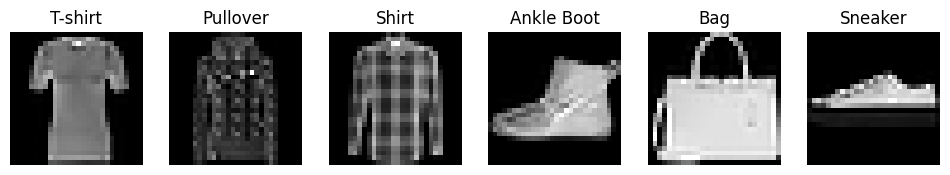

In [11]:
# Visualize Dataset
dataiter = iter(trainloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 6, figsize=(12,4))
for i in range(6):
    axes[i].imshow(images[i][0], cmap='gray')
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')
plt.show()
#visual for the categories

In [12]:
class DualAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // 4)
        self.fc2 = nn.Linear(channels // 4, channels)
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        b, c, h, w = x.size()
         # Channel Attention
        avg_pool = torch.mean(x, dim=(2,3))
        ca = torch.relu(self.fc1(avg_pool))
        ca = torch.sigmoid(self.fc2(ca)).view(b, c, 1, 1)
        x = x * ca
        # Spatial Attention (FIXED)
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa = torch.cat([avg_out, max_out], dim=1)
        sa = self.conv(sa)
        sa = torch.sigmoid(sa / 5)  # prevent saturation
        x = x * sa

        return x, ca, sa
# Dual Attention Mechanism that enhances feature learning by sequentially recalibrating Channel Attention
#(identifying "what" features are globally important) and Spatial Attention (pinpointing "where" those features are located in the image).

In [13]:
# Model
class ExplainableCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(1, 32, 3),nn.ReLU(),nn.MaxPool2d(2) )
        self.conv2 = nn.Sequential(nn.Conv2d(32, 64, 3),nn.ReLU(),nn.MaxPool2d(2))
        self.attention = DualAttention(64)
        self.fc1 = nn.Linear(64*5*5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x, ca, sa = self.attention(x)
        self.feature_maps = x
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x, ca, sa
# CNN architecture uses standard convolutional blocks
#for feature extraction and integrates a Dual Attention module to weight important features before classification

In [15]:
# Setup of CNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ExplainableCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses = []

In [16]:
epochs = 27
for epoch in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _, _ = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
#training loop executes the backpropagation algorithm over 27 epochs
#updating the model's weights by calculating the loss on each batch

Epoch 1, Loss: 0.5230
Epoch 2, Loss: 0.3321
Epoch 3, Loss: 0.2824
Epoch 4, Loss: 0.2496
Epoch 5, Loss: 0.2253
Epoch 6, Loss: 0.2051
Epoch 7, Loss: 0.1851
Epoch 8, Loss: 0.1700
Epoch 9, Loss: 0.1508
Epoch 10, Loss: 0.1386
Epoch 11, Loss: 0.1244
Epoch 12, Loss: 0.1129
Epoch 13, Loss: 0.1003
Epoch 14, Loss: 0.0877
Epoch 15, Loss: 0.0822
Epoch 16, Loss: 0.0711
Epoch 17, Loss: 0.0645
Epoch 18, Loss: 0.0593
Epoch 19, Loss: 0.0528
Epoch 20, Loss: 0.0490
Epoch 21, Loss: 0.0461
Epoch 22, Loss: 0.0425
Epoch 23, Loss: 0.0380
Epoch 24, Loss: 0.0366
Epoch 25, Loss: 0.0309
Epoch 26, Loss: 0.0303
Epoch 27, Loss: 0.0326


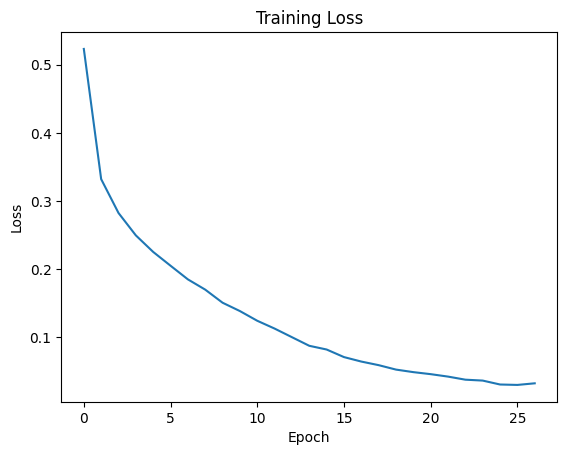

In [17]:
# visualization of the loss
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [18]:
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs, _, _ = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("Accuracy:", 100 * correct / total)
# printing the accuracy of the model

Accuracy: 91.54


In [19]:
labels_map = {
    0 : "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot" }

In [20]:
# Get batch
dataiter = iter(testloader)
images, labels = next(dataiter)
images = images.to(device)
labels = labels.to(device)

In [21]:
# Forward pass
outputs, ca, sa = model(images)
_, preds = torch.max(outputs, 1)
images_cpu = images.cpu()

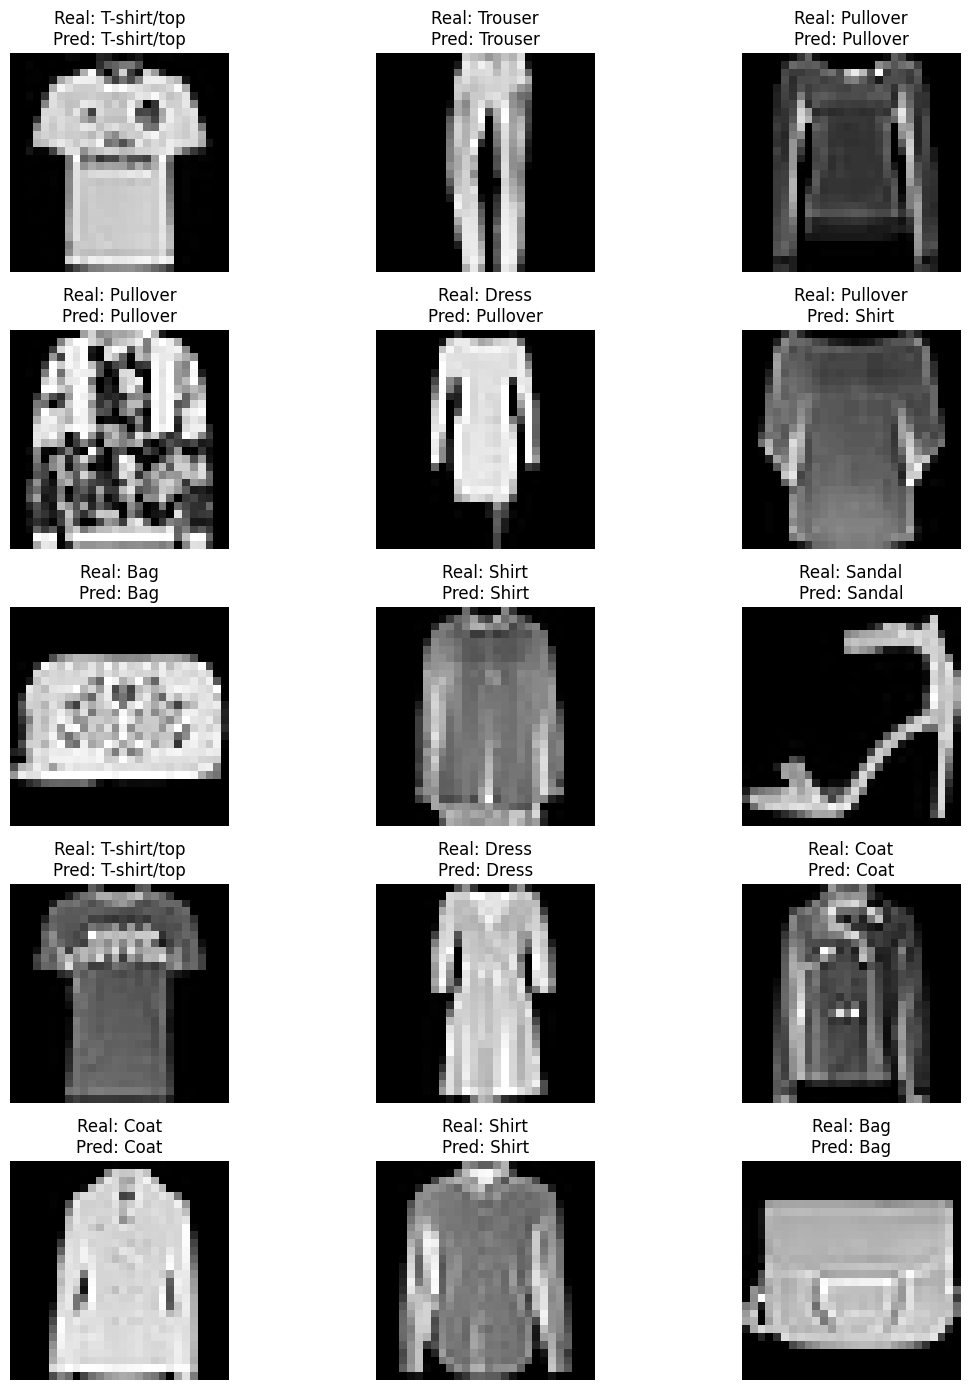

In [24]:
#  1. ORIGINAL IMAGE + PREDICTION GRID
fig, axes = plt.subplots(5, 3, figsize=(12, 14))
for i, ax in enumerate(axes.flat):
    img = images_cpu[i][0]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {labels_map[labels[i].item()]}\nPred: {labels_map[preds[i].item()]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

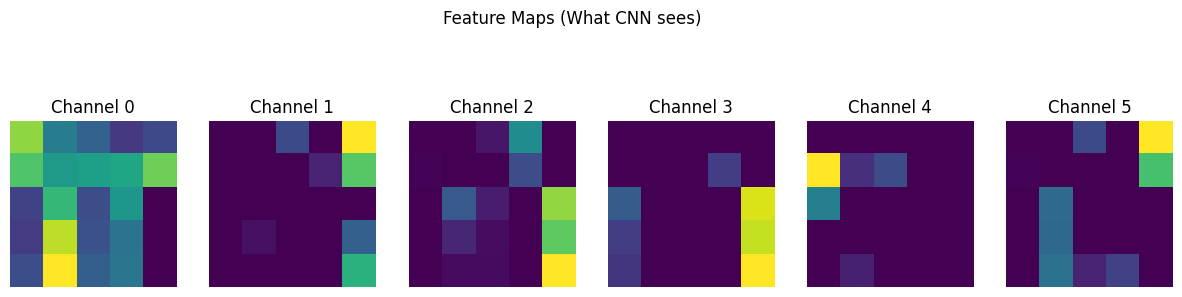

In [23]:
#  2. FEATURE MAP VISUALIZATION (FIRST 6 CHANNELS)
feature_maps = model.feature_maps.detach().cpu()
fig, axes = plt.subplots(1, 6, figsize=(15,4))
for i in range(6):
    axes[i].imshow(feature_maps[0][i], cmap='viridis')
    axes[i].set_title(f"Channel {i}")
    axes[i].axis('off')
plt.suptitle("Feature Maps (What CNN sees)")
plt.show()

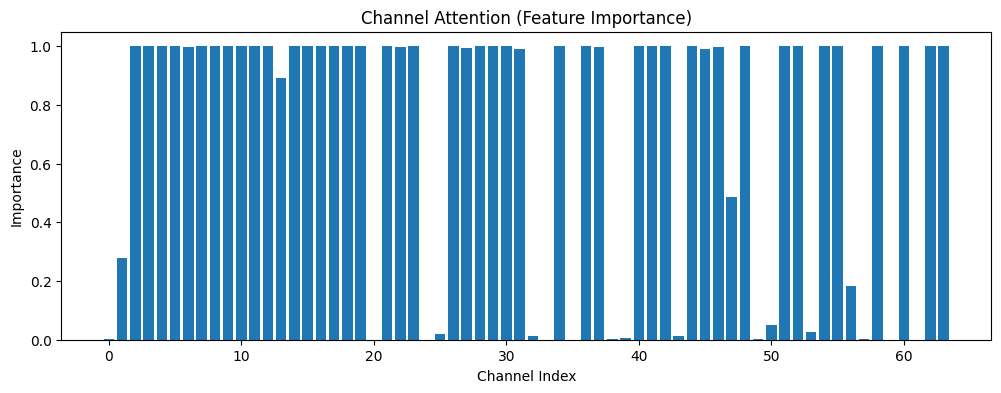

In [25]:
#  3. CHANNEL ATTENTION (WHAT IS IMPORTANT)
ca_values = ca[0].detach().cpu().view(-1)
plt.figure(figsize=(12,4))
plt.bar(range(len(ca_values)), ca_values)
plt.title("Channel Attention (Feature Importance)")
plt.xlabel("Channel Index")
plt.ylabel("Importance")
plt.show()

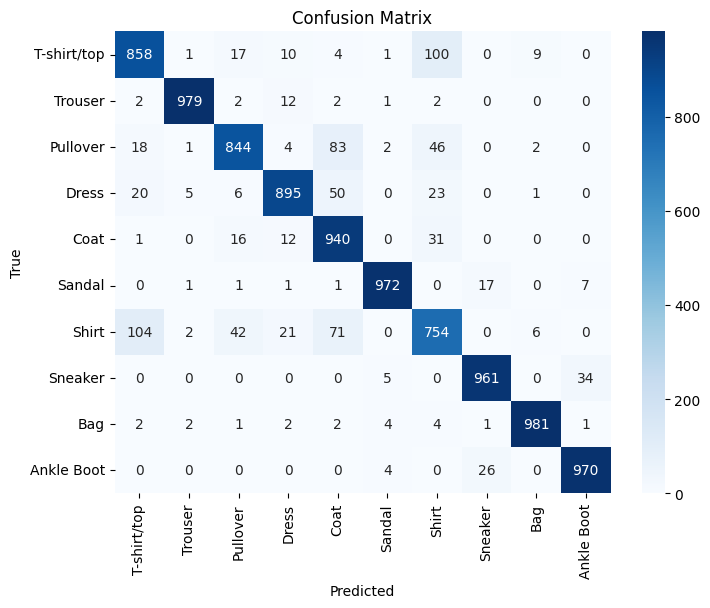

In [26]:
# 4. CONFUSION MATRIX

all_preds = []
all_labels = []
with torch.no_grad():
    for img, lbl in testloader:
        img, lbl = img.to(device), lbl.to(device)
        out, _, _ = model(img)
        _, pred = torch.max(out, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(labels_map.values()),
            yticklabels=list(labels_map.values()))

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


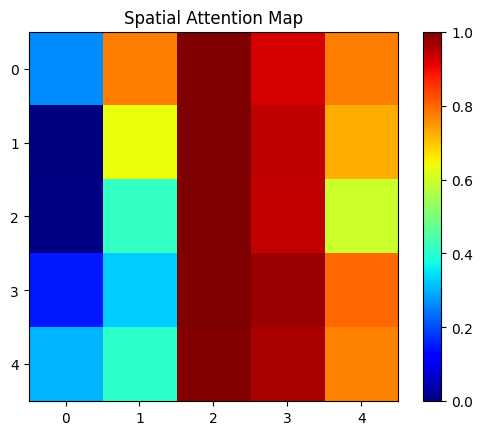

In [28]:
# 5.SPATIAL ATTENTION

sa_map = sa[0][0].detach().cpu()
sa_map = (sa_map - sa_map.min()) / (sa_map.max() - sa_map.min() + 1e-8)
plt.imshow(sa_map, cmap='jet')
plt.title("Spatial Attention Map")
plt.colorbar()
plt.show()

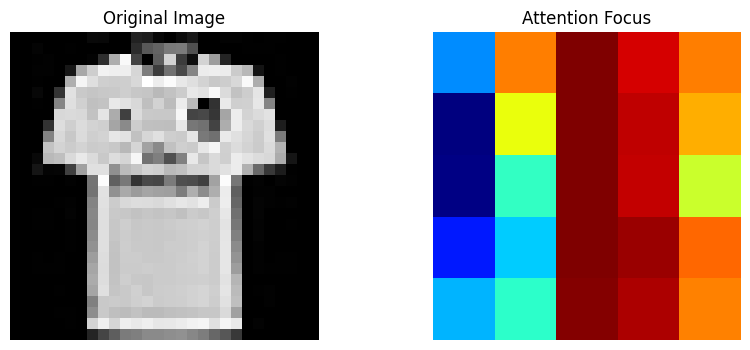

In [29]:
#6.IMAGE+ ATTENTION
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(images_cpu[0][0], cmap='gray')
ax[0].set_title("Original Image")

ax[1].imshow(sa_map, cmap='jet')
ax[1].set_title("Attention Focus")

for a in ax:
    a.axis('off')

In [30]:
#end-to-end pipeline that takes raw Fashion MNIST data and passes it through a specialized CNN. By adding the Dual Attention layer,
#the model doesn't just guess the clothing type—it actually "looks" at specific parts of the image to make its decision.
#This makes the whole process much more transparent and shows exactly what the AI is focusing on. Overall
#the model trained well and gives us a solid, explainable way to handle image classification.

SyntaxError: unterminated string literal (detected at line 2) (1917086967.py, line 2)